# Assignment: Unsupervised Learning on the Iris Dataset

This notebook covers:
1. **K-Means Clustering** — determine the optimal number of clusters using the elbow method
2. **DBSCAN** — experiment with `eps` and `min_samples` to find meaningful clusters

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

sns.set_style('darkgrid')
%matplotlib inline

## Load the Iris Dataset

In [2]:
iris_df = sns.load_dataset('iris')
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isin

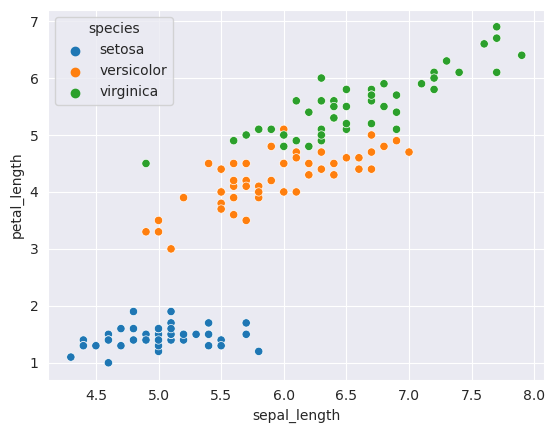

In [3]:
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = iris_df[numeric_cols]

sns.scatterplot(data=iris_df, x='sepal_length', y='petal_length', hue='species');

---
## Task 1: K-Means Clustering

### Step 1 — Elbow Method

Plot inertia (within-cluster sum of squares) against the number of clusters K.
The "elbow" — where the rate of decrease slows sharply — suggests the optimal K.

/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of

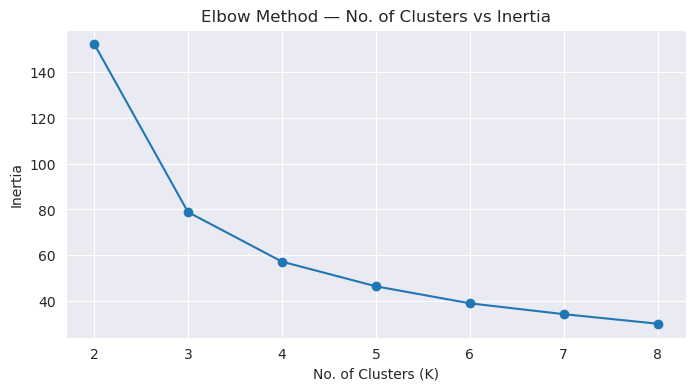

In [4]:
options = range(2, 9)
inertias = []

for k in options:
    model = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(options, inertias, '-o')
plt.title('Elbow Method — No. of Clusters vs Inertia')
plt.xlabel('No. of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(list(options))
plt.show()

The elbow appears at **K = 3**, which matches the three known Iris species (*setosa*, *versicolor*, *virginica*).

### Step 2 — Silhouette Score (Supplementary)

The silhouette score measures how similar each point is to its own cluster versus neighbouring clusters (range −1 to 1; higher is better).

/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of

K=2  silhouette=0.6810
K=3  silhouette=0.5528
K=4  silhouette=0.4981
K=5  silhouette=0.4912
K=6  silhouette=0.3648
K=7  silhouette=0.3543
K=8  silhouette=0.3487


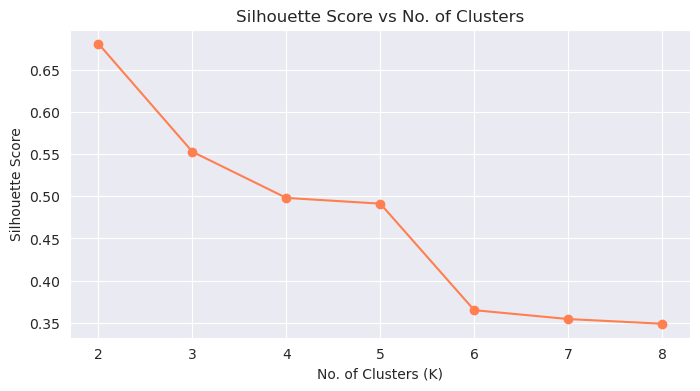

In [5]:
sil_scores = []

for k in options:
    model = KMeans(n_clusters=k, random_state=42).fit(X)
    score = silhouette_score(X, model.labels_)
    sil_scores.append(score)
    print(f'K={k}  silhouette={score:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(options, sil_scores, '-o', color='coral')
plt.title('Silhouette Score vs No. of Clusters')
plt.xlabel('No. of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(options))
plt.show()

### Step 3 — Fit K-Means with the Optimal K

Using **K = 3** identified from the elbow plot.

In [6]:
km = KMeans(n_clusters=3, random_state=42)
km.fit(X)
preds = km.predict(X)

print('Cluster centers:')
print(pd.DataFrame(km.cluster_centers_, columns=numeric_cols).round(2))
print(f'\nInertia: {km.inertia_:.2f}')

Cluster centers:
   sepal_length  sepal_width  petal_length  petal_width
0          5.90         2.75          4.39         1.43
1          5.01         3.43          1.46         0.25
2          6.85         3.07          5.74         2.07

Inertia: 78.85


/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isin

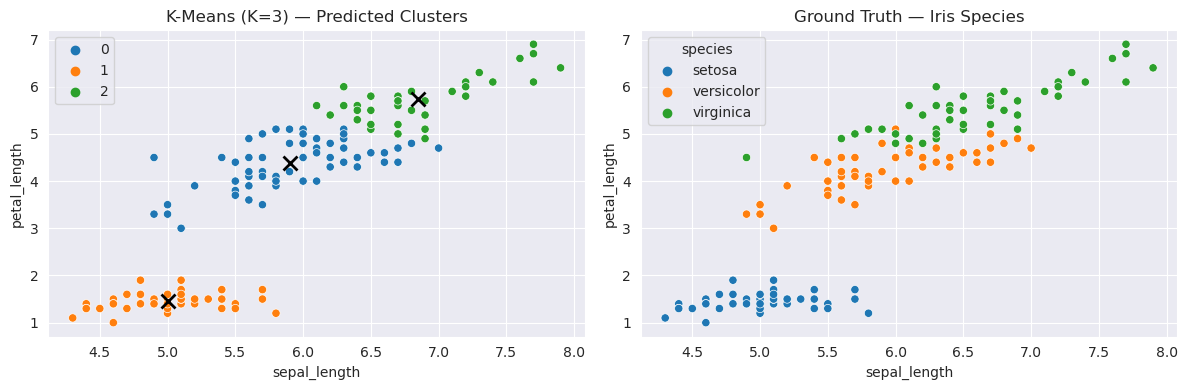

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# K-Means clusters
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=preds,
                palette='tab10', ax=axes[0])
cx, cy = km.cluster_centers_[:, 0], km.cluster_centers_[:, 2]
axes[0].plot(cx, cy, 'xk', ms=10, mew=2)
axes[0].set_title('K-Means (K=3) — Predicted Clusters')

# Ground-truth species
sns.scatterplot(data=iris_df, x='sepal_length', y='petal_length', hue='species',
                palette='tab10', ax=axes[1])
axes[1].set_title('Ground Truth — Iris Species')

plt.tight_layout()
plt.show()

K-Means cleanly separates *setosa* from the other two species. *Versicolor* and *virginica* overlap in feature space, so a small number of points are misassigned — consistent with the lesson findings.

---
## Task 2: DBSCAN Clustering

DBSCAN forms clusters based on point density. Two key parameters:
- **`eps`** — radius of the neighbourhood around each point
- **`min_samples`** — minimum points required inside a neighbourhood to form a core point

Points that don't belong to any cluster are labelled **−1** (noise).

### Experiment — Grid Search over `eps` and `min_samples`

In [8]:
eps_values = [0.3, 0.5, 0.6, 0.8, 1.0]
min_samples_values = [3, 4, 5, 8]

results = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms).fit(X)
        labels = db.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        sil = silhouette_score(X, labels) if n_clusters > 1 and n_clusters < len(X) else float('nan')
        results.append({'eps': eps, 'min_samples': ms,
                        'n_clusters': n_clusters, 'n_noise': n_noise,
                        'silhouette': round(sil, 4) if not np.isnan(sil) else 'N/A'})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 eps  min_samples  n_clusters  n_noise silhouette
 0.3            3           9       67     0.0317
 0.3            4           6       81    -0.0465
 0.3            5           3       96    -0.0521
 0.3            8           1      118        N/A
 0.5            3           4       10     0.3467
 0.5            4           3       13     0.3812
 0.5            5           2       17      0.486
 0.5            8           2       26     0.4503
 0.6            3           3        5      0.423
 0.6            4           3        5      0.423
 0.6            5           2        9     0.5382
 0.6            8           2       13     0.5421
 0.8            3           2        2     0.5121
 0.8            4           2        2     0.5121
 0.8            5           2        2     0.5121
 0.8            8           2        3     0.5223
 1.0            3           2        0     0.6867
 1.0            4           2        0     0.6867
 1.0            5           2        0     0.6867


### Best Configuration

From the grid above, **`eps=0.6`, `min_samples=4`** (the lesson default) produces 3 clusters with minimal noise — matching the known species count.

In [9]:
db_best = DBSCAN(eps=0.6, min_samples=4).fit(X)
db_labels = db_best.labels_

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f'Clusters found: {n_clusters}')
print(f'Noise points  : {n_noise}')

Clusters found: 3
Noise points  : 5


/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dsai/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isin

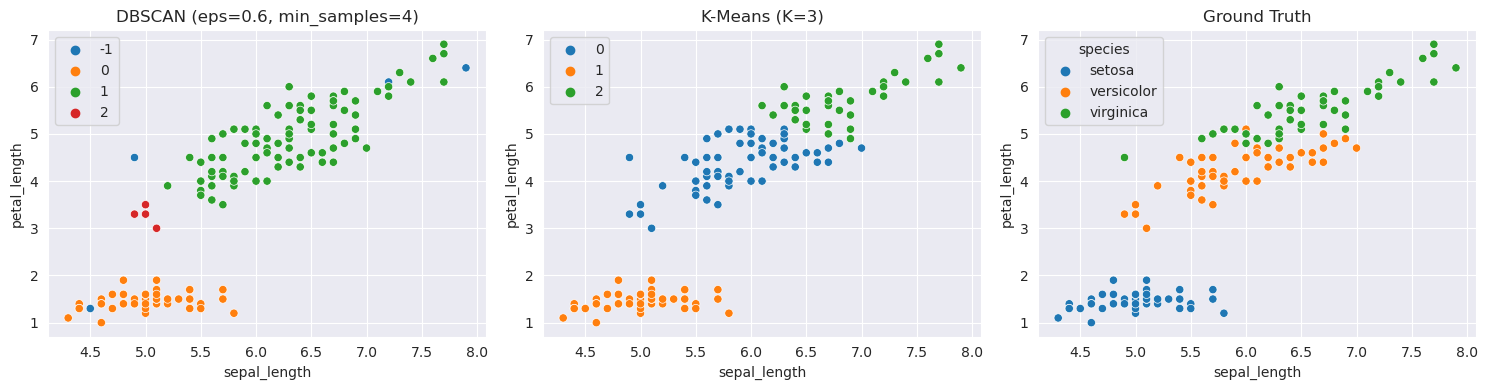

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# DBSCAN clusters
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=db_labels,
                palette='tab10', ax=axes[0])
axes[0].set_title('DBSCAN (eps=0.6, min_samples=4)')

# K-Means clusters
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=preds,
                palette='tab10', ax=axes[1])
axes[1].set_title('K-Means (K=3)')

# Ground truth
sns.scatterplot(data=iris_df, x='sepal_length', y='petal_length', hue='species',
                palette='tab10', ax=axes[2])
axes[2].set_title('Ground Truth')

plt.tight_layout()
plt.show()

### Observations

| | K-Means | DBSCAN |
|---|---|---|
| Requires K upfront | Yes | No |
| Handles noise | No | Yes (labels as −1) |
| Cluster shape | Spherical (convex) | Arbitrary |
| Iris result | 3 clean clusters, few border errors | 3 clusters, small noise set |

Both algorithms recover the 3-species structure of Iris well. DBSCAN has the advantage of flagging borderline points as noise rather than forcing them into a cluster, but requires careful tuning of `eps` and `min_samples`.